- Author: Yousef Al Zeer

## Imports

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay   # New
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
fpath = "/content/drive/MyDrive/Intro to ML /Week 3/Core/stroke.csv"
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


## EDA

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,52


In [ ]:
df.describe()

,id,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,1137.000000,1137.000000,1137.000000,1137.000000,1085.000000,1137.000000
mean,36750.933157,0.118734,0.068602,107.664002,29.198065,0.120493
std,21112.281253,0.323617,0.252887,47.618723,7.669615,0.325680
min,77.000000,0.000000,0.000000,55.270000,11.300000,0.000000
25%,17986.000000,0.000000,0.000000,77.600000,24.100000,0.000000
50%,37479.000000,0.000000,0.000000,91.820000,28.500000,0.000000
75%,55410.000000,0.000000,0.000000,113.850000,33.200000,0.000000
max,72918.000000,1.000000,1.000000,266.590000,64.400000,1.000000


- BMI column contains missing values that require imputation. Since the mean is slightly higher than the median, there is slight right-skewness .

- No unrealistic/impossible values were observed across the dataset

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,642
Male,494
Other,1


In [ ]:
df['age'].unique()

array(['31', '13', '18', '65', '4', '28', '64', '62', '26', '63', '50',
       '77', '1', '52', '24', '48', '45', '74', '3', '17', '54', '55',
       '67', '35', '38', '81', '34', '44', '79', '56', '70', '30', '39',
       '29', '80', '59', '51', '19', '43', '71', '0', '23', '53', '78',
       '66', '60', '76', '22', '6', '47', '2', '46', '11', '33', '37',
       '49', '61', '75', '40', '8', '57', '12', '21', '41', '58', '27',
       '20', '68', '42', '5', '69', '9', '36', '25', '82', '73', '32',
       '7', '16', '14', '72', '15', '10', '*82'], dtype=object)

In [ ]:
df['age'] = df['age'].str.strip()
df['age'] = df['age'].str.replace('*' , '')

In [ ]:
df['age'] = df['age'].astype(int)

In [ ]:
df.dtypes

,0
id,int64
gender,object
age,int64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [ ]:
df['ever_married'].value_counts()

,count
ever_married,
Yes,769
No,368


In [ ]:
df['stroke'].value_counts(normalize=True)


,proportion
stroke,
0,0.879507
1,0.120493


- The dataset is imbalanced , with only 12% of instances belonging to the positive class (Stroke)

## PreProcessing

### Train-Test

In [ ]:
cols_drop = ['id']
# Create features matrix and target vector
X = df.drop(columns = [*cols_drop, 'stroke'])
y = df['stroke']
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)
y_train.value_counts(normalize=True).sort_index()

,proportion
stroke,
0,0.879108
1,0.120892


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 852 entries, 72 to 1126
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             852 non-null    object 
 1   age                852 non-null    int64  
 2   hypertension       852 non-null    int64  
 3   heart_disease      852 non-null    int64  
 4   ever_married       852 non-null    object 
 5   work_type          852 non-null    object 
 6   Residence_type     852 non-null    object 
 7   avg_glucose_level  852 non-null    float64
 8   bmi                812 non-null    float64
 9   smoking_status     852 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 73.2+ KB


### Numeric

In [ ]:
# Numerical Prepprocessing Pipeline
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')


### Categorical

In [ ]:
# Categorical Preprocessing Pipeline

ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
impute_na = SimpleImputer(strategy='constant', fill_value = "Missing")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns: Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


In [ ]:
preprocessor = ColumnTransformer([num_tuple, ohe_tuple], verbose_feature_names_out=False)

## Default Decision Tree

In [ ]:
dec_tree = DecisionTreeClassifier(random_state = 42)
dec_tree_pipe = make_pipeline(preprocessor , dec_tree)
dec_tree_pipe.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

## Evaluation

In [ ]:
# Define the predicted values
y_pred_train = dec_tree_pipe.predict(X_train)
y_pred_test = dec_tree_pipe.predict(X_test)
# Obtain the accuracy score
train_acc = accuracy_score(y_pred_train, y_train)
test_acc = accuracy_score(y_pred_test, y_test)
# Print the results
print(f'Training accuracy : {train_acc:.4f}.')
print(f'Testing accuracy  : {test_acc:.4f}.')

Training accuracy : 1.0000.
Testing accuracy  : 0.8386.


In [ ]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [ ]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



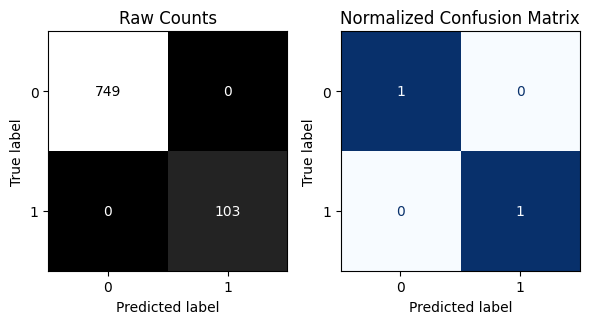


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       251
           1       0.29      0.24      0.26        34

    accuracy                           0.84       285
   macro avg       0.59      0.58      0.58       285
weighted avg       0.83      0.84      0.83       285



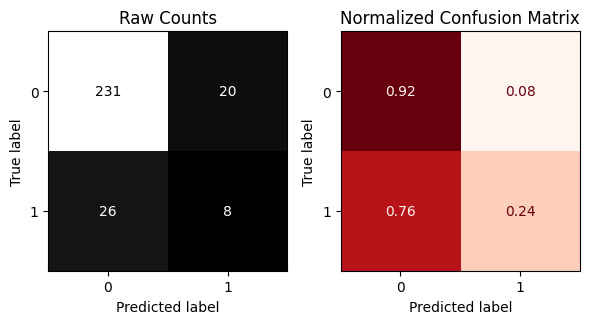

In [ ]:
results = evaluate_classification(dec_tree_pipe,X_train, y_train, X_test, y_test,output_dict=False)

### 1. Overall Accuracy and Performance

  - The overall accuracy of the model is 84%

  - Performance: The high accuracy here is misleading due to severe class imbalance. The model achieves this score by simply favoring the majority class while failing to reliably detect actual stroke cases . . the primary goal of this task.


### 2. Unnecessary Alerts (False Positive)

  - Based on the Matrix, 20 patients were predicted to have a stroke but did not.

  - Approximately 8% of patients who did not have a stroke were incorrectly predicted to have one.


### 3. Missed Warnings (False Negative)

  - Based on the Matrix, 26 patients were predicted not to have a stroke but actually did.

 - The model failed to identify 76% of patients who actually had a stroke


### 4. Metric to Optimize

  - In this case, **Recall** is the most important metric to optimize.

  - the cost of a False Negative (failing to identify a stroke) is much higher than the cost of a False Positive (false alarm).Therefore, the model must prioritize capturing as many positive cases as possible even at the cost of lower precision , as this is the most critical goal in this task.
  
  - Minimize the risk of missing any patient who requires immediate medical attention.




- The model suffers from **severe overfitting**, as there is a large gap between the training and testing sets. While it performed well on the training data, it failed to generalize to unseen cases.

- There is a significant difference between the macro avg and the weighted avg. The weighted mean is much higher, indicating that the model is heavily biased towards the majority category (without a stroke).This indicates that the model is performing well on the easy to predict majority class while failing the minority class.